In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.constants as cc
import astropy.units as u
from astropy.table import Table


In [2]:
import matplotlib
# matplotlib.rcParams.update({'font.size':18})
matplotlib.rcParams.update({'font.family':'serif'})

# https://github.com/dhaitz/mplcyberpunk
# import mplcyberpunk
# plt.style.use("cyberpunk")

In [3]:
# https://iopscience.iop.org/article/10.1088/0004-637X/804/2/144#apj511277t1
a15 = pd.read_table('Anderson2015.txt', delim_whitespace=True)


/var/folders/8t/yh7p62792_b_y17g3f6wk0wm0000gn/T/ipykernel_34740/2072491371.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  a15 = pd.read_table('Anderson2015.txt', delim_whitespace=True)


In [4]:
# https://iopscience.iop.org/article/10.1088/0004-637X/794/1/80#apj500194app1
e14 = pd.read_table('Engle2014_Tbl4.txt', delim_whitespace=True)
e14.columns

/var/folders/8t/yh7p62792_b_y17g3f6wk0wm0000gn/T/ipykernel_34740/2763298651.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  e14 = pd.read_table('Engle2014_Tbl4.txt', delim_whitespace=True)


Index(['HJD', 'Phase', 'V-mag', 'error', 'HJD.1', 'Phase.1', 'U-B', 'error.1',
       'HJD.2', 'Phase.2', 'B-V', 'error.2', 'HJD.3', 'Phase.3', 'V-R',
       'error.3', 'HJD.4', 'Phase.4', 'R-I', 'error.4'],
      dtype='object')

Text(0, 0.5, '$m_V$ (mag)')

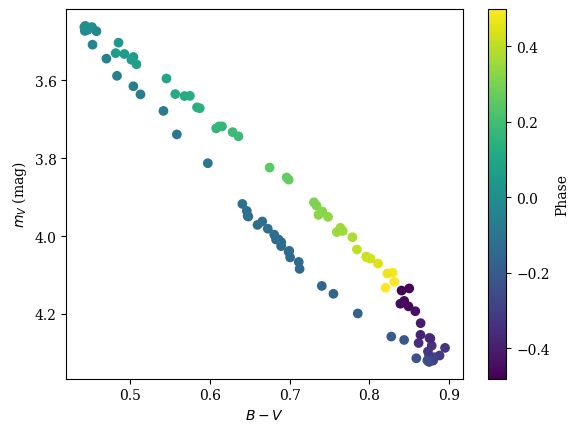

In [5]:
plt.scatter(e14['B-V'],e14['V-mag'], c=e14['Phase'])
plt.gca().invert_yaxis()
cb = plt.colorbar()
cb.set_label('Phase')
plt.xlabel('$B-V$')
plt.ylabel('$m_V$ (mag)')

In [6]:
# https://www.aanda.org/articles/aa/full_html/2015/12/aa25954-15/aa25954-15.html
# http://cdsarc.u-strasbg.fr/ftp/J/A+A/584/A80/ReadMe
# m15 = pd.read_table('delcep1.dat', delim_whitespace=True)

tbl = Table.read('delta_Cep.fits', format='fits', hdu=2)
tbl.columns

<TableColumns names=('PHASE','Vpuls','Vrad','diam','Teff','Lum','logg','diamK 100m','diamK 200m','diamK 300m','MAG B_MVB_TYCHO','MAG HP_MVB_HIPPARCOS','MAG V_MVB_TYCHO','MAG V_GCPD','MAG K_CTIO','COLOR B_GCPD-V_GCPD','COLOR J_CTIO-K_CTIO','COLOR H_CTIO-K_CTIO')>

In [7]:
tbl1 = Table.read('delta_Cep.fits', format='fits', hdu=1)
df = tbl1.to_pandas()
sum(df['OBS'].astype('str').str.contains('diam'))

67

In [8]:
# df['MEAS'][df['OBS'].astype('str').str.contains('diam')]
# df.columns
df['OBS'][df['OBS'].astype('str').str.contains('diam')].astype('str').str.split(',',expand=True)[1].str.split(']', expand=True)[0].astype('float')

0     165.553
1     163.060
2     157.715
3     166.600
4     164.990
       ...   
62    133.075
63    137.750
64    110.862
65    117.810
66    123.037
Name: 0, Length: 67, dtype: float64

In [9]:
dd = df['OBS'].astype('str').str.contains('diam')
DIAM = df['OBS'][dd].astype('str').str.split(',',expand=True)[1].str.split(']', expand=True)[0].astype('float')
aok = DIAM > 180

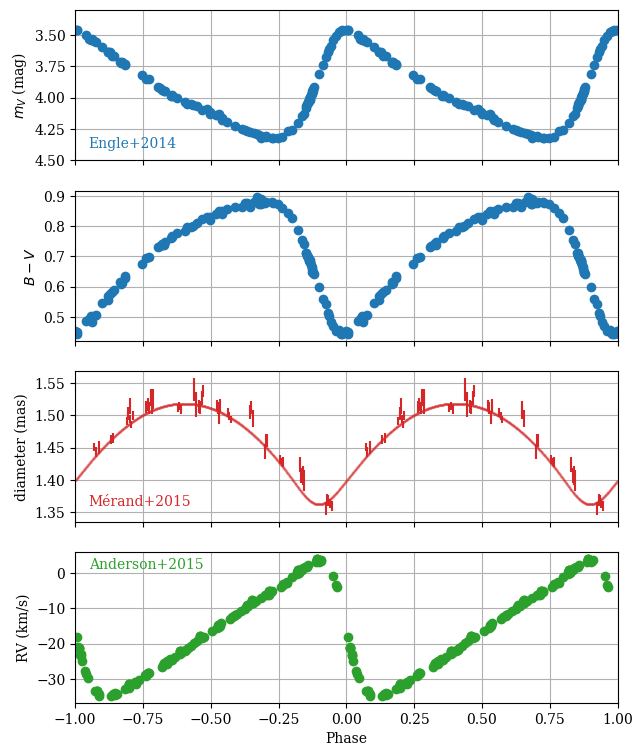

In [10]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(7,9))

axs[0].scatter(e14['Phase'], e14['V-mag'], c='C0')
axs[0].scatter(e14['Phase']-1, e14['V-mag'], c='C0')
axs[0].scatter(e14['Phase']+1, e14['V-mag'], c='C0')
axs[0].set_ylim(4.5,3.3)
axs[0].set_ylabel('$m_V$ (mag)')
axs[0].text(-.95,4.4, 'Engle+2014', c='C0')

axs[1].scatter(e14['Phase.2'], e14['B-V'])
axs[1].scatter(e14['Phase.2']-1, e14['B-V'], c='C0')
axs[1].scatter(e14['Phase.2']+1, e14['B-V'], c='C0')
axs[1].set_ylabel('$B-V$')

axs[2].scatter(tbl['PHASE'], tbl['diam'], c='C3',s=1, alpha=0.16)
axs[2].scatter(tbl['PHASE']-1, tbl['diam'], c='C3',s=1, alpha=0.16)
axs[2].errorbar(df['PHASE'][dd][aok], 
             df['MEAS'][dd][aok], 
             yerr=df['ERR'][dd][aok], linestyle='none', c='C3')
axs[2].errorbar(df['PHASE'][dd][aok]-1, 
             df['MEAS'][dd][aok], 
             yerr=df['ERR'][dd][aok], linestyle='none', c='C3')
axs[2].text(-.95, 1.36, 'Mérand+2015', c='C3')
axs[2].set_ylabel('diameter (mas)')

axs[3].scatter(a15['Phase'], a15['RV'], c='C2')
axs[3].scatter(a15['Phase']-1, a15['RV'], c='C2')
axs[3].set_ylabel('RV (km/s)')
axs[3].text(-.95,1, 'Anderson+2015', c='C2')

axs[3].set_xlabel('Phase')
axs[3].set_xlim([-1, 1])

axs[1].set_axisbelow(True)
axs[1].grid()
axs[2].set_axisbelow(True)
axs[2].grid()
axs[3].set_axisbelow(True)
axs[3].grid()
axs[0].set_axisbelow(True)
axs[0].grid()


plt.savefig('Delta_Cephei.png', dpi=150, bbox_inches='tight', pad_inches=0.25)

In [11]:
np.median(a15['RV'])

-17.908

In [12]:
(np.max(a15['RV']) + np.min(a15['RV'])) / 2

-15.400500000000001